# Fase 1 - Data Analytics - Analise de dados Storytelling


## Aula 3 - Analisando dados com python I

In [10]:
# Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [11]:
# Lê o arquivo Excel e armazena no DataFrame df_dengue
df_dengue = pd.read_excel('/content/sample_data/Base de Dados Dengue.xlsx')

# Exibe as primeiras 5 linhas do DataFrame (índice começa em 0)
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


In [12]:
# Exibe as últimas 5 linhas do DataFrame
df_dengue.tail()

,municipio,uf,data_infeccoes,qtd_infeccoes
728767,BRASILIA,DF,2023-08-01,939
728768,BRASILIA,DF,2023-09-01,843
728769,BRASILIA,DF,2023-10-01,686
728770,BRASILIA,DF,2023-11-01,1300
728771,BRASILIA,DF,2023-12-01,5603


## Aula 3 - Analisando dados com python II

In [17]:
# Retorna a quantidade de linhas e colunas do DataFrame: df_dengue.shape
print(f'Tamanho do DataSet: {df_dengue.shape}')

Tamanho do DataSet: (728772, 4)


In [19]:
# Retorna o tipo de dado de cada coluna do DataFrame (object geralmente representa texto)
df_dengue.dtypes

,0
municipio,object
uf,object
data_infeccoes,datetime64[ns]
qtd_infeccoes,int64


In [21]:
# Verifica valores nulos no DataFrame, indicando onde há dados ausentes (True para nulo, False para preenchido)
df_dengue.isnull()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
728767,False,False,False,False
728768,False,False,False,False
728769,False,False,False,False
728770,False,False,False,False


In [22]:
# Retorna a quantidade de valores nulos por coluna, auxiliando na identificação de dados ausentes
df_dengue.isnull().sum()

,0
municipio,0
uf,0
data_infeccoes,0
qtd_infeccoes,0


In [25]:
# Retorna o total geral de valores nulos no DataFrame, somando todas as colunas
# df_dengue.isnull().sum().sum()

print(f'Quantidade de dados nulos: {df_dengue.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [28]:
# Exibe informações gerais do DataFrame, como quantidade de linhas, colunas, tipos de dados e valores não nulos
df_dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728772 entries, 0 to 728771
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   municipio       728772 non-null  object        
 1   uf              728772 non-null  object        
 2   data_infeccoes  728772 non-null  datetime64[ns]
 3   qtd_infeccoes   728772 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 22.2+ MB


In [30]:
# Retorna a quantidade de valores únicos em cada coluna do DataFrame
df_dengue.nunique()

,0
municipio,5243
uf,27
data_infeccoes,132
qtd_infeccoes,1157


Calcular a quantidade de pessoas que pegaram dengue por ano

In [37]:
# Cria uma nova coluna com o ano extraído da coluna de data de infecções
df_dengue ['ano'] = df_dengue['data_infeccoes'].dt.year
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34,2013
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44,2013
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15,2013
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4,2013
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3,2013


In [43]:
# Agrupa os dados por ano, município e UF, somando a quantidade de infecções e reorganizando o índice
infeccoes_minicipio = df_dengue.groupby(['ano', 'municipio', 'uf'])['qtd_infeccoes'].sum().reset_index()
infeccoes_minicipio.head()

,ano,municipio,uf,qtd_infeccoes
0,2013,ABADIA DE GOIAS,GO,52
1,2013,ABADIA DOS DOURADOS,MG,0
2,2013,ABADIANIA,GO,37
3,2013,ABAETE,MG,486
4,2013,ABAETETUBA,PA,15


In [44]:
infeccoes_minicipio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60731 entries, 0 to 60730
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ano            60731 non-null  int32 
 1   municipio      60731 non-null  object
 2   uf             60731 non-null  object
 3   qtd_infeccoes  60731 non-null  int64 
dtypes: int32(1), int64(1), object(2)
memory usage: 1.6+ MB


In [52]:
# Agrupa os dados por ano e UF, somando a quantidade de infecções por estado
infeccoes_estado = df_dengue.groupby(['ano', 'uf'])['qtd_infeccoes'].sum().reset_index()
infeccoes_estado.head()

,ano,uf,qtd_infeccoes
0,2013,AC,1663
1,2013,AL,704
2,2013,AM,4327
3,2013,AP,546
4,2013,BA,13417


## Aula 3 - Analisando dados com python III


# Estatistica descritiva

In [58]:
# Retorna estatísticas descritivas das colunas numéricas do DataFrame, como média, mínimo, máximo e desvio padrão
infeccoes_estado.describe()

,ano,qtd_infeccoes
count,297.000000,297.000000
mean,2018.000000,12872.474747
std,3.167615,31630.107741
min,2013.000000,0.000000
25%,2015.000000,780.000000
50%,2018.000000,2229.000000
75%,2021.000000,10098.000000
max,2023.000000,286000.000000


## Análise dos resultados (2013 a 2023)

Ao analisar os dados de infecções por estado ao longo de 2013 a 2023, observa-se que a média anual de casos foi de aproximadamente 128 mil infecções.

O desvio padrão elevado (cerca de 316 mil) indica uma grande variação nos dados ao longo dos anos, demonstrando que existem períodos com picos significativos de casos.

O valor mínimo registrado foi 0, indicando ausência de casos em determinados registros, enquanto o valor máximo atingiu aproximadamente 2,86 milhões de infecções, evidenciando surtos expressivos.

A mediana (50%) foi de aproximadamente 22 mil casos, o que mostra que metade dos registros está abaixo desse valor, indicando que os grandes picos influenciam a média.

Os quartis reforçam essa dispersão:
- 25% dos dados estão abaixo de 780 casos
- 75% estão abaixo de aproximadamente 101 mil casos

De forma geral, os dados apresentam alta variabilidade, com ocorrência de surtos ao longo dos anos analisados.

In [59]:
infeccoes_estado.shape

(297, 3)

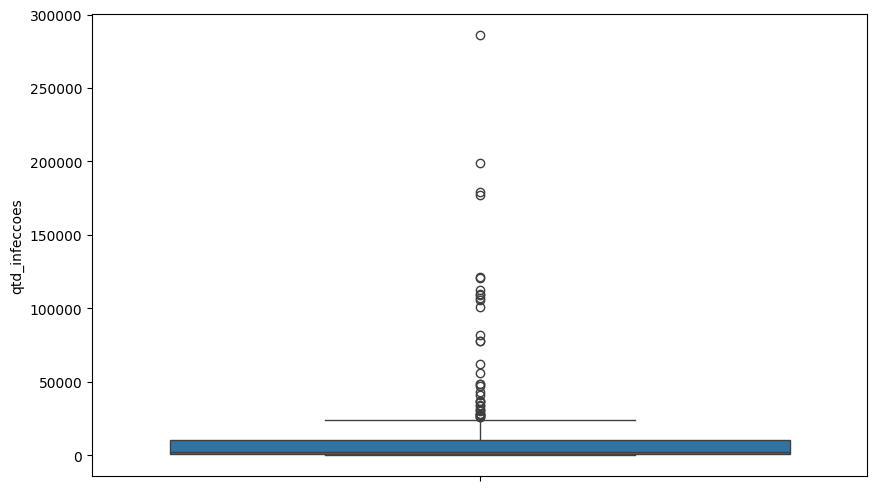

In [64]:
# Cria um gráfico boxplot para visualizar a distribuição das infecções, destacando a mediana, dispersão dos dados e possíveis outliers

# Define o tamanho da figura do gráfico (largura e altura)
plt.figure(figsize=(10, 6))
# Cria um boxplot utilizando os dados da coluna 'qtd_infeccoes', mostrando distribuição, mediana e outliers
sns.boxplot(data = infeccoes_estado, y = 'qtd_infeccoes')
plt.show()

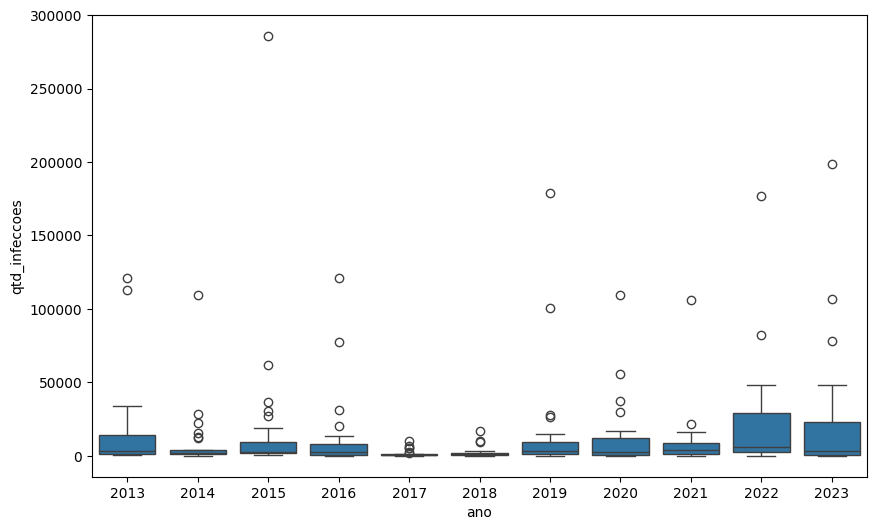

In [67]:
plt.figure(figsize=(10, 6))
# Cria um boxplot para analisar a distribuição das infecções por ano, permitindo visualizar variações, mediana e outliers ao longo do tempo
sns.boxplot(data = infeccoes_estado, x = 'ano', y = 'qtd_infeccoes')
plt.show()

# Interpretação do boxplot:
# Caixa (box) → intervalo interquartil (Q1 a Q3)
# Linha central → mediana
# Pontos (bolinhas) → outliers (valores fora do padrão)

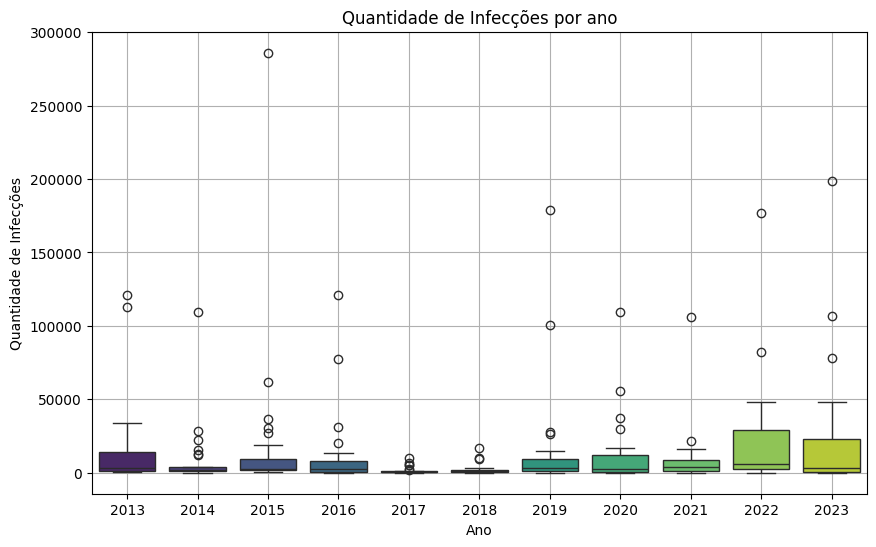

In [81]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(10, 6))
# Cria um boxplot para analisar a distribuição das infecções por ano, evidenciando a mediana, a variação dos dados (quartis) e a presença de valores extremos (outliers)
sns.boxplot(data = infeccoes_estado,
            x = 'ano',
            y = 'qtd_infeccoes',
            palette ='viridis'
            )

# Personalizar o gráfico
plt.title('Quantidade de Infecções por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Infecções')
plt.grid(True)

plt.show()

In [91]:
# Exibe o DataFrame com todas as colunas e linhas
infeccoes_estado

,ano,uf,qtd_infeccoes
0,2013,AC,1663
1,2013,AL,704
2,2013,AM,4327
3,2013,AP,546
4,2013,BA,13417
...,...,...,...
292,2023,RS,27389
293,2023,SC,77954
294,2023,SE,1749
295,2023,SP,198774


In [87]:
# Filtra os dados para o ano de 2023, retornando apenas as infecções por estado nesse período
infeccoes_estado_2023 = infeccoes_estado[infeccoes_estado['ano'] == 2023]
infeccoes_estado_2023

,ano,uf,qtd_infeccoes
270,2023,AC,1781
271,2023,AL,473
272,2023,AM,3263
273,2023,AP,742
274,2023,BA,13249
275,2023,CE,7437
276,2023,DF,23710
277,2023,ES,0
278,2023,GO,21682
279,2023,MA,2428


In [92]:
# Filtra os dados utilizando .loc, selecionando apenas os registros do ano de 2023.
# A função .loc é utilizada para selecionar dados no DataFrame com base em rótulos (nomes de colunas ou índices), permitindo aplicar filtros e escolher colunas simultaneamente
infeccoes_estado_2023 = infeccoes_estado.loc[infeccoes_estado['ano'] == 2023]
infeccoes_estado_2023

,ano,uf,qtd_infeccoes
270,2023,AC,1781
271,2023,AL,473
272,2023,AM,3263
273,2023,AP,742
274,2023,BA,13249
275,2023,CE,7437
276,2023,DF,23710
277,2023,ES,0
278,2023,GO,21682
279,2023,MA,2428


In [109]:
infeccoes_estado_2023.describe()

,ano,qtd_infeccoes
count,27.0,27.000000
mean,2023.0,22902.888889
std,0.0,43368.215001
min,2023.0,0.000000
25%,2023.0,744.000000
50%,2023.0,3263.000000
75%,2023.0,22696.000000
max,2023.0,198774.000000


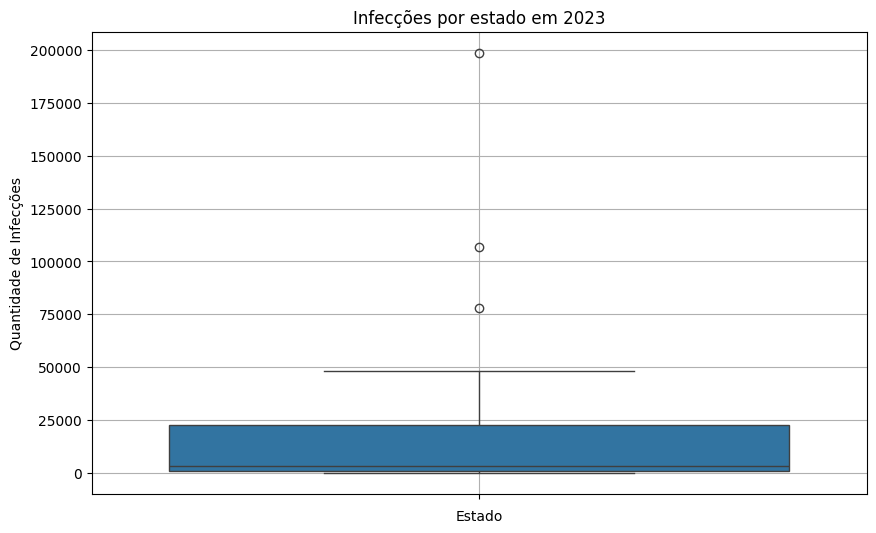

In [110]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = infeccoes_estado_2023, y = 'qtd_infeccoes')
plt.title('Infecções por estado em 2023')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Infecções')
plt.grid(True)
plt.show()

In [113]:
# Biblioteca utilizada para criação de gráficos interativos e visualizações de dados
import plotly.express as px

# Cria um gráfico boxplot interativo para visualizar a distribuição das infecções por estado (UF) no ano de 2023, utilizando cores para diferenciar cada estado
fig = px.box(infeccoes_estado_2023,
            x = 'uf',
            y = 'qtd_infeccoes',
            color = 'uf',
            title = 'Infecções por estado em 2023'
            )

fig.show()

In [114]:
# Gera um boxplot interativo para avaliar a distribuição das infecções por estado em 2023,
# permitindo identificar a mediana, dispersão dos dados (quartis) e possíveis outliers (valores extremos)
figI = px.box(infeccoes_estado_2023,
            y = 'qtd_infeccoes',
            title = 'Infecções por estado em 2023'
            )

figI.show()